In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, t, ttest_ind

%matplotlib inline

In [2]:
repository_path = pathlib.Path.cwd().parents[2]
bgg_path = repository_path / "data" / "bgg"

In [3]:
bgg_games_data = pd.read_csv(bgg_path / "games.csv")
bgg_mechanics_data = pd.read_csv(bgg_path / "mechanics.csv")

# Hypothesis 4 - Semi-cooperative vs fully cooperative ratings on BGG

## 4.1 Question and pre-registered test

**Question.** Do semi-cooperative games rate differently from fully cooperative games on BoardGameGeek?

- **$H_0$:** the mean `BayesAvgRating` of semi-cooperative games equals the mean of fully cooperative games.
- **$H_1$:** the two means differ.

**Data.** BGG only. A game is **semi-cooperative** if `mechanics.csv` has `Semi-Cooperative Game == 1`, and **fully cooperative** if `Cooperative Game == 1` and `Semi-Cooperative Game == 0`. Games with both flags are classified as semi-cooperative to keep the groups disjoint. The comparison is limited to games with `NumUserRatings >= 500` so the Bayesian rating is based on a non-trivial sample.

**Test.** Two-sample Welch t-test on `BayesAvgRating`. The non-parametric Mann-Whitney U-test is reported alongside as a robustness check, since the semi-cooperative group is small and may be sensitive to skew. Significance level $\alpha = 0.05$.

**Decision rule.** Reject $H_0$ if the p-value is below the Holm-corrected threshold.

## 4.2 Data preparation

Steps:

1. Strip BGG's column-name idiosyncrasies (colons in the games table for `Cat:Strategy` etc., spaces and hyphens in the mechanics table for `Cooperative Game` and `Semi-Cooperative Game`) so all column names become valid Python identifiers.
2. Merge games with mechanics on `BGGId`.
3. Classify each game as semi-cooperative or fully cooperative.
4. Keep only games with `NumUserRatings >= 500` so the Bayesian rating is based on a non-trivial sample.
5. Extract the `BayesAvgRating` series for each group.

In [4]:
def reformat_columns(columns):
    return (columns
            .str.replace(r":([a-z])", lambda m: m.group(1).upper(), regex = True)
            .str.replace(":", "")
            .str.replace(" ", "")
            .str.replace("-", ""))


bgg_games_data.columns = reformat_columns(bgg_games_data.columns)
bgg_mechanics_data.columns = reformat_columns(bgg_mechanics_data.columns)

In [5]:
bgg_games_with_mechanics = bgg_games_data.merge(bgg_mechanics_data, on = "BGGId")

is_semi_cooperative = bgg_games_with_mechanics["SemiCooperativeGame"] == 1
is_fully_cooperative = (bgg_games_with_mechanics["CooperativeGame"] == 1) & ~is_semi_cooperative
has_reliable_rating = bgg_games_with_mechanics["NumUserRatings"] >= 500

semi_coop_ratings = bgg_games_with_mechanics.loc[is_semi_cooperative & has_reliable_rating, "BayesAvgRating"]
coop_ratings = bgg_games_with_mechanics.loc[is_fully_cooperative & has_reliable_rating, "BayesAvgRating"]

print(f"Semi-cooperative games (n):  {len(semi_coop_ratings)}")
print(f"Fully cooperative games (n): {len(coop_ratings)}")

Semi-cooperative games (n):  24
Fully cooperative games (n): 495


## 4.3 Per-group mean and 95% confidence interval

For each group, compute the mean `BayesAvgRating` and a 95% CI using the Student t-distribution (`mean ± t_{0.975, n-1} * SE`). With both groups in the hundreds the t-distribution is essentially normal, but t-quantiles keep the CI valid if either sample shrinks.

In [6]:
def mean_with_ci(values, confidence = 0.95):
    sample_size = len(values)
    mean = values.mean()
    standard_error = values.std(ddof = 1) / np.sqrt(sample_size)
    margin = t.ppf((1 + confidence) / 2, df = sample_size - 1) * standard_error
    return sample_size, mean, mean - margin, mean + margin


semi_coop_n, semi_coop_mean, semi_coop_lower, semi_coop_upper = mean_with_ci(semi_coop_ratings)
coop_n, coop_mean, coop_lower, coop_upper = mean_with_ci(coop_ratings)

group_summary = pd.DataFrame([
    {"group": "semi-cooperative", "n": semi_coop_n, "mean": semi_coop_mean,
     "ci_lower": semi_coop_lower, "ci_upper": semi_coop_upper},
    {"group": "fully cooperative", "n": coop_n, "mean": coop_mean,
     "ci_lower": coop_lower, "ci_upper": coop_upper},
]).set_index("group")

overall_mean = pd.concat([semi_coop_ratings, coop_ratings]).mean()

print(f"Overall mean BayesAvgRating: {overall_mean:.4f}")
group_summary

Overall mean BayesAvgRating: 6.3545


,n,mean,ci_lower,ci_upper
group,,,,
semi-cooperative,24,6.509839,6.239957,6.779722
fully cooperative,495,6.346918,6.297866,6.395970


**Chart.** Mean BayesAvgRating per group with 95% CI. The dashed line marks the overall mean across the union of both groups. A bar whose CI does not cross the dashed line sits significantly above or below the average at the 5% level.

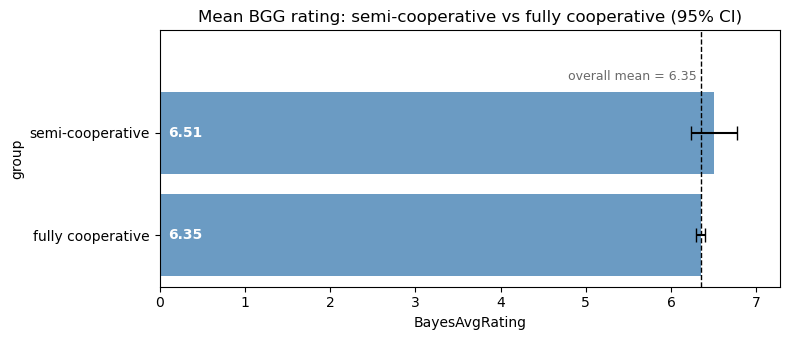

In [7]:
positions = np.arange(len(group_summary))
errors_lower = group_summary["mean"].values - group_summary["ci_lower"].values
errors_upper = group_summary["ci_upper"].values - group_summary["mean"].values

plt.figure(figsize = (8, 3.5))

plt.barh(positions, group_summary["mean"].values, color = "steelblue", alpha = 0.8)

plt.errorbar(group_summary["mean"].values, positions, xerr = [errors_lower, errors_upper],
             fmt = "none", color = "black", capsize = 5)

plt.axvline(overall_mean, color = "black", linestyle = "--", linewidth = 1)
plt.text(overall_mean - 0.05, -0.55, f"overall mean = {overall_mean:.2f}",
         va = "center", ha = "right", fontsize = 9, color = "dimgray")

plt.yticks(positions, group_summary.index)
plt.xlabel("BayesAvgRating")
plt.ylabel("group")
plt.xlim(0, group_summary["ci_upper"].max() + 0.5)
plt.ylim(-1.0, len(group_summary) - 0.5)
plt.title("Mean BGG rating: semi-cooperative vs fully cooperative (95% CI)")

for i, mean_value in enumerate(group_summary["mean"].values):
    plt.text(0.1, i, f"{mean_value:.2f}", va = "center", ha = "left",
             color = "white", fontweight = "bold", fontsize = 10)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**Distribution check.** The Welch t-test relies on the *means* being approximately normally distributed under sampling - which is fine in practice once the sample sizes are in the hundreds, but heavily skewed source distributions can still pull the t-statistic. The histograms below let us eyeball whether the two groups have similar shapes and how skewed each one is. The Mann-Whitney U-test in 4.5 is the rank-based fallback that does not depend on shape.

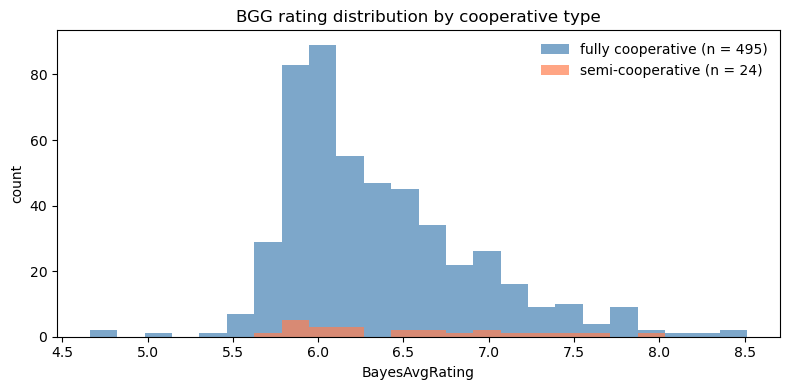

In [8]:
plt.figure(figsize = (8, 4))

bin_edges = np.linspace(
    min(semi_coop_ratings.min(), coop_ratings.min()),
    max(semi_coop_ratings.max(), coop_ratings.max()),
    25,
)

plt.hist(coop_ratings, bins = bin_edges, color = "steelblue", alpha = 0.7,
         label = f"fully cooperative (n = {coop_n})")
plt.hist(semi_coop_ratings, bins = bin_edges, color = "coral", alpha = 0.7,
         label = f"semi-cooperative (n = {semi_coop_n})")

plt.xlabel("BayesAvgRating")
plt.ylabel("count")
plt.title("BGG rating distribution by cooperative type")
plt.legend(frameon = False)

plt.tight_layout()

plt.show()

## 4.4 Welch's two-sample t-test

The Welch t-test does not assume equal variances between the two groups, so it is the right primary test here - the semi-cooperative and fully cooperative populations have no a priori reason to share the same dispersion. The test is run two-sided since we have no directional prior.

In [9]:
welch_result = ttest_ind(semi_coop_ratings, coop_ratings, equal_var = False)

print(f"t-statistic:        {welch_result.statistic:.4f}")
print(f"degrees of freedom: {welch_result.df:.1f}")
print(f"p-value:            {welch_result.pvalue:.4e}")

t-statistic:        1.2265
degrees of freedom: 24.7
p-value:            2.3155e-01


## 4.5 Mann-Whitney U robustness check

The Mann-Whitney U-test compares the rank distributions of the two groups and does not assume any shape for the source distributions. If the t-test and the Mann-Whitney test agree, the conclusion is robust to skew in the rating distributions.

In [10]:
mannwhitney_result = mannwhitneyu(semi_coop_ratings, coop_ratings, alternative = "two-sided")

print(f"U-statistic: {mannwhitney_result.statistic:.4f}")
print(f"p-value:     {mannwhitney_result.pvalue:.4e}")

U-statistic: 6721.0000
p-value:     2.7668e-01


## 4.6 Decision

The Welch t-test gives $t = 1.23$ on 24.7 degrees of freedom with $p = 0.232$, well above $\alpha = 0.05$. The Mann-Whitney U-test agrees ($p = 0.277$), so the conclusion is not driven by skew in either rating distribution. We **fail to reject $H_0$**: the BGG data do not provide evidence that semi-cooperative games rate differently from fully cooperative games.

The observed mean ratings are 6.51 for semi-cooperative and 6.35 for fully cooperative - a difference of about +0.16 in favour of semi-cooperative - but with only 24 semi-cooperative games passing the `NumUserRatings >= 500` filter, the per-group standard error is too large to call this difference at the 5% level. The semi-cooperative group's CI [6.24, 6.78] and the fully cooperative group's CI [6.30, 6.40] overlap heavily.

This is a **low-power null**, not a strong null. The semi-cooperative tag on BGG is rare; to distinguish a real ~0.15 rating gap from noise we would need a much larger sample of semi-cooperative games, which the BGG data simply does not contain. Sticking with the pre-registered scope, **the cross-source evidence on the cooperative/semi-cooperative axis does not support a balance claim either way for *Volcano Rush*'s hybrid design**. This should be flagged as a power limitation in the discussion section of the main notebook.